# Moving Average Decomposition (`Moving_Decomp`)

Classical **moving-average decomposition** splits a univariate (or channel-wise multivariate) series into two additive pieces:

$$
y_t = T_t + S_t,
$$

where $T_t$ is a **slowly varying trend** estimated by a smoother, and $S_t = y_t - T_t$ is the residual **cycle / seasonality / noise**.  There is no inner optimisation loop: once the smoother is chosen, the residual is an identity.

PySDKit implements this in `pysdkit.tsa.Moving_Decomp`, with five interchangeable smoothers from `pysdkit.utils`:

| `method` | Helper | Idea |
|---|---|---|
| `simple` | `simple_moving_average` | uniform (rectangular) window |
| `weighted` | `weighted_moving_average` | linearly increasing weights |
| `gaussian` | `gaussian_smoothing` | Gaussian low-pass (`sigma`) |
| `savgol` | `savgol_smoothing` | local polynomial (Savitzky–Golay) |
| `exponential` | `exponential_smoothing` | causal SES (`alpha`) |

This notebook derives the five kernels, then **overlays all of them on one figure** so the lag, overshoot and residual leakage can be compared directly.


## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import Moving_Decomp
from pysdkit.utils import (
    simple_moving_average,
    weighted_moving_average,
    gaussian_smoothing,
    savgol_smoothing,
    exponential_smoothing,
)
from pysdkit.data import generate_time_series

print(Moving_Decomp())
print("methods:", Moving_Decomp().methods_list)

Moving Average decomposition (Moving_Decomp)
methods: ['simple', 'weighted', 'gaussian', 'savgol', 'exponential']


## 2. Principle: estimate the trend, the rest is the cycle

A moving-average smoother is a (possibly causal) linear filter

$$
T_t = \sum_{k} w_k\, y_{t-k}, \qquad \sum_k w_k = 1.
$$

PySDKit then **defines** the second component by subtraction:

$$
S_t := y_t - T_t.
$$

Reconstruction is therefore exact for every method: $T_t + S_t = y_t$.  What *does* change with the kernel is

- how much high-frequency energy leaks into $T$ (under-smoothing) or is stripped into $S$ (over-smoothing);
- whether the trend **lags** the data (causal SES) or is centred (two-sided MA / Gaussian / Savitzky–Golay);
- how the smoother behaves at turning points (polynomial SG vs. rectangular MA).

This is the same additive split used in classical census X-11 / Henderson MA, and a lightweight alternative to STL when you only need a trend + remainder.


## 3. The five smoothers

Let $W$ be an odd window length (PySDKit default `window_size=5`).

**Simple MA** — rectangular kernel, `numpy.convolve(..., mode="same")`:

$$
w_k = \frac{1}{W}, \qquad k = 0,\ldots,W-1.
$$

**Weighted MA** — linearly increasing weights (more mass on one side of the window):

$$
w_k = \frac{k+1}{\sum_{j=1}^{W} j} = \frac{2(k+1)}{W(W+1)}.
$$

**Gaussian** — two-sided `scipy.ndimage.gaussian_filter1d`, width `sigma` (default 2).  In the frequency domain this is a Gaussian low-pass: larger $\sigma$ means a slower trend.

**Savitzky–Golay** — fit a polynomial of order `poly_order` (default 2) in each window of length $W$ and take the fitted value at the centre.  Compared with a plain MA it preserves peaks better and can follow a quadratic trend without lag.

**Exponential (SES)** — causal recursion with smoothing factor `alpha` $\in (0,1)$ (default 0.4):

$$
T_0 = y_0, \qquad T_t = \alpha y_t + (1-\alpha)\, T_{t-1}.
$$

Equivalent kernel $w_k = \alpha(1-\alpha)^k$ on the past only, so the trend **lags** a rising/falling slope.  Larger $\alpha$ tracks the data more tightly (less smoothing).


## 4. A series with a known trend and cycle

To make the five kernels comparable we build an additive toy series whose trend and seasonal pieces are known:

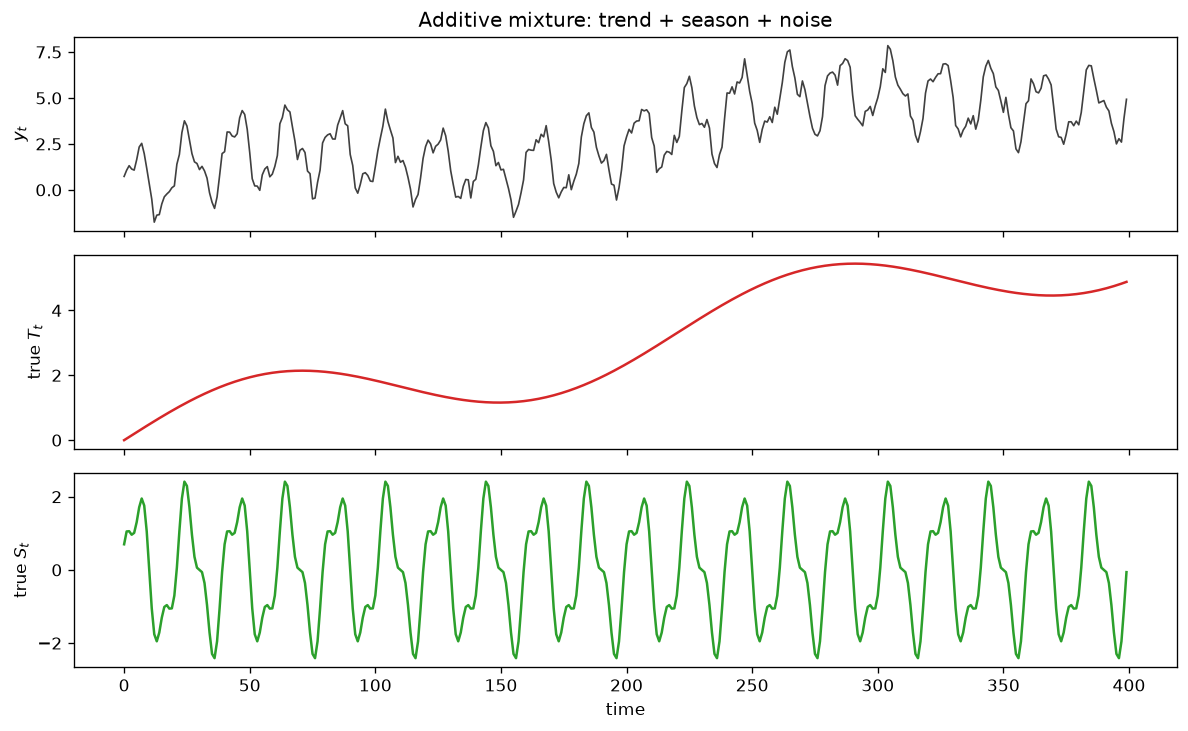

In [2]:
rng = np.random.default_rng(0)
n = 400
t = np.arange(n, dtype=float)
trend_true = 0.015 * t + 1.2 * np.sin(2.0 * np.pi * t / 220.0)
season_true = 1.8 * np.sin(2.0 * np.pi * t / 20.0) + 0.7 * np.cos(2.0 * np.pi * t / 8.0)
noise = 0.25 * rng.standard_normal(n)
y = trend_true + season_true + noise

fig, axes = plt.subplots(3, 1, figsize=(10, 6.2), sharex=True)
axes[0].plot(t, y, color="0.25", lw=1.0)
axes[0].set_ylabel("$y_t$")
axes[0].set_title("Additive mixture: trend + season + noise")
axes[1].plot(t, trend_true, color="C3")
axes[1].set_ylabel("true $T_t$")
axes[2].plot(t, season_true, color="C2")
axes[2].set_ylabel("true $S_t$")
axes[2].set_xlabel("time")
fig.tight_layout()
plt.show()

## 5. All five methods in one figure

Each method is run through `Moving_Decomp` with the same window $W=15$ (odd, as required by Savitzky–Golay).  Gaussian uses `sigma=3` so its effective width is in the same ballpark; SES uses the library default `alpha=0.4`.

The overlay is the point of the notebook: **one panel for every trend, one panel for every remainder**.

simple        max |T+S-y| = 2.22e-16   RMSE(T) = 0.483
weighted      max |T+S-y| = 1.94e-16   RMSE(T) = 0.670
gaussian      max |T+S-y| = 1.11e-16   RMSE(T) = 0.831
savgol        max |T+S-y| = 1.11e-16   RMSE(T) = 1.165
exponential   max |T+S-y| = 1.11e-16   RMSE(T) = 1.133


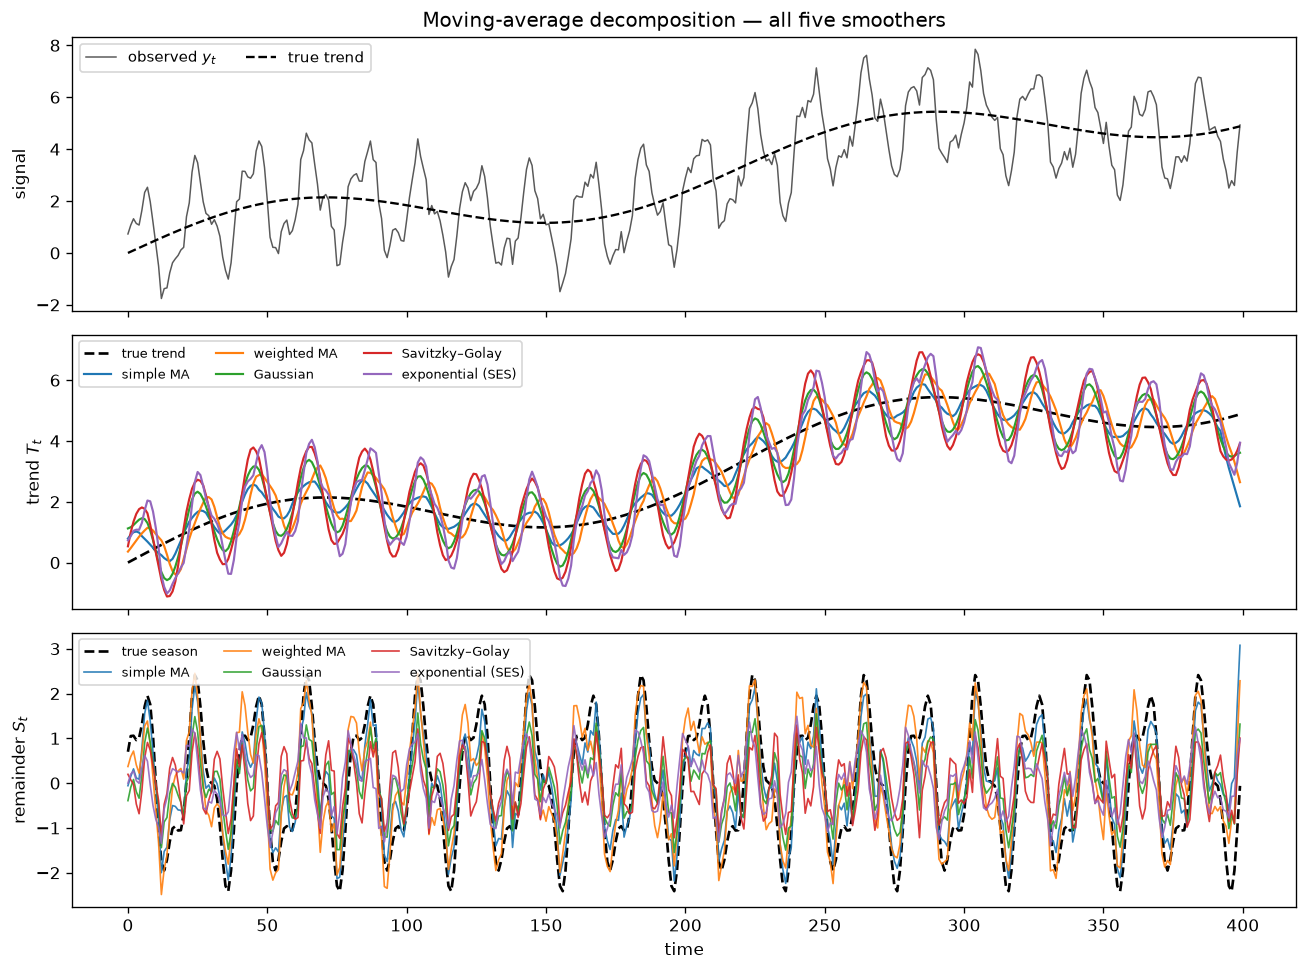

In [3]:
METHODS = ["simple", "weighted", "gaussian", "savgol", "exponential"]
COLORS = {
    "simple": "C0",
    "weighted": "C1",
    "gaussian": "C2",
    "savgol": "C3",
    "exponential": "C4",
}
LABELS = {
    "simple": "simple MA",
    "weighted": "weighted MA",
    "gaussian": "Gaussian",
    "savgol": "Savitzky–Golay",
    "exponential": "exponential (SES)",
}

window_size = 15
results = {}
for method in METHODS:
    decomp = Moving_Decomp(
        window_size=window_size,
        method=method,
        sigma=3,
        poly_order=2,
        alpha=0.4,
    )
    trend, season = decomp.fit_transform(y)
    results[method] = {"trend": trend, "season": season}
    recon_err = np.max(np.abs(trend + season - y))
    trend_rmse = np.sqrt(np.mean((trend - trend_true) ** 2))
    print(f"{method:12s}  max |T+S-y| = {recon_err:.2e}   RMSE(T) = {trend_rmse:.3f}")

fig, axes = plt.subplots(3, 1, figsize=(11, 8.2), sharex=True)
axes[0].plot(t, y, color="0.35", lw=0.9, label="observed $y_t$")
axes[0].plot(t, trend_true, color="k", ls="--", lw=1.4, label="true trend")
axes[0].set_ylabel("signal")
axes[0].set_title("Moving-average decomposition — all five smoothers")
axes[0].legend(loc="upper left", ncol=2, fontsize=9)

axes[1].plot(t, trend_true, color="k", ls="--", lw=1.6, label="true trend")
for method in METHODS:
    axes[1].plot(
        t,
        results[method]["trend"],
        color=COLORS[method],
        lw=1.3,
        label=LABELS[method],
    )
axes[1].set_ylabel("trend $T_t$")
axes[1].legend(loc="upper left", ncol=3, fontsize=8)

axes[2].plot(t, season_true, color="k", ls="--", lw=1.6, label="true season")
for method in METHODS:
    axes[2].plot(
        t,
        results[method]["season"],
        color=COLORS[method],
        lw=1.0,
        alpha=0.9,
        label=LABELS[method],
    )
axes[2].set_ylabel("remainder $S_t$")
axes[2].set_xlabel("time")
axes[2].legend(loc="upper left", ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

What the overlay typically shows:

- **Simple MA** is a boxcar: the trend is a bit blocky and the seasonal amplitude in $S_t$ is well recovered, but turning points are rounded.
- **Weighted MA** is not symmetric, so the trend sits slightly off the true slope compared with the centred boxcar.
- **Gaussian** is the smoothest two-sided trend (no ringing from a hard cutoff).
- **Savitzky–Golay** follows the slow sinusoid in $T_t$ more tightly than a boxcar of the same $W$, because a quadratic can fit a bend inside the window.
- **Exponential** is causal: on an upward slope the trend **lags**, so part of the genuine trend leaks into $S_t$.  That is the price of a one-sided smoother (online / streaming use).


## 6. Impulse responses of the five kernels

A unit impulse makes the linear filters themselves visible.  Two-sided methods peak at the impulse; SES only looks at the past, so its mass sits *after* $t=0$ in the causal direction (here: to the right).

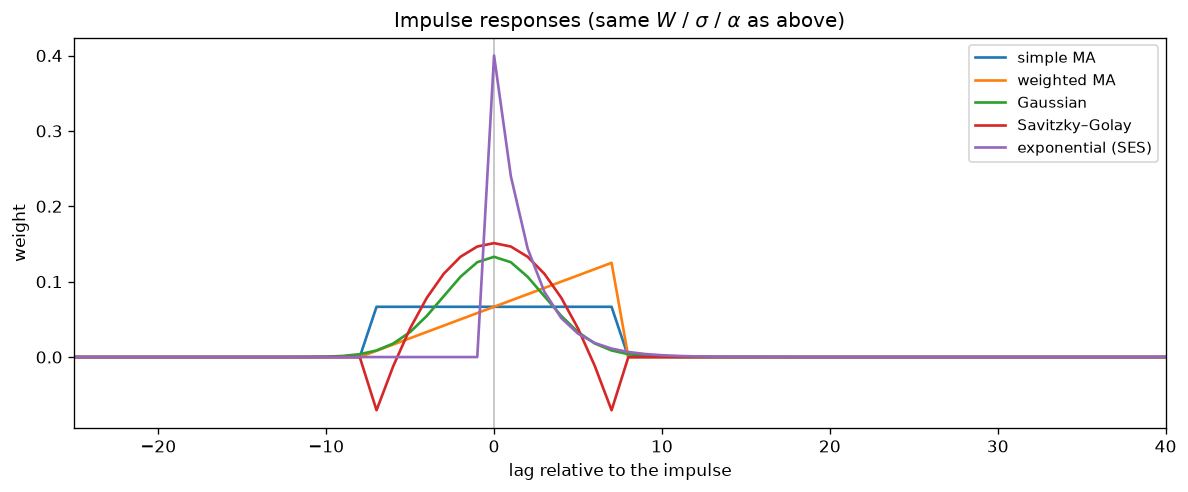

In [4]:
impulse = np.zeros(81)
impulse[40] = 1.0
k = np.arange(impulse.size) - 40

kernels = {
    "simple": simple_moving_average(impulse, window_size=window_size),
    "weighted": weighted_moving_average(impulse, window_size=window_size),
    "gaussian": gaussian_smoothing(impulse, sigma=3),
    "savgol": savgol_smoothing(impulse, window_length=window_size, poly_order=2),
    "exponential": exponential_smoothing(impulse, alpha=0.4),
}

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.axvline(0.0, color="0.75", lw=1.0)
for method in METHODS:
    ax.plot(k, kernels[method], color=COLORS[method], lw=1.6, label=LABELS[method])
ax.set_xlim(-25, 40)
ax.set_xlabel("lag relative to the impulse")
ax.set_ylabel("weight")
ax.set_title("Impulse responses (same $W$ / $\\sigma$ / $\\alpha$ as above)")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

## 7. Window length vs. smoothness

For a centred MA, $W$ is the main bandwidth knob: larger $W$ pulls more of the 20-sample season into the trend (over-smoothing).  The figure below keeps `method="simple"` and varies $W$.

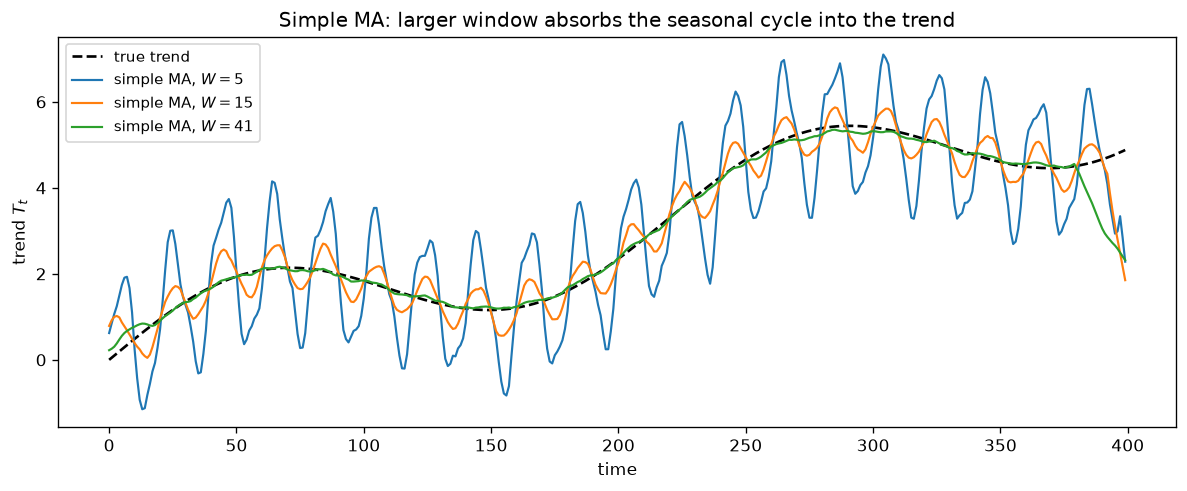

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(t, trend_true, color="k", ls="--", lw=1.6, label="true trend")
for w, ls in zip([5, 15, 41], ["-", "-", "-"]):
    trend_w, _ = Moving_Decomp(window_size=w, method="simple").fit_transform(y)
    ax.plot(t, trend_w, lw=1.3, label=f"simple MA, $W={w}$")
ax.set_xlabel("time")
ax.set_ylabel("trend $T_t$")
ax.set_title("Simple MA: larger window absorbs the seasonal cycle into the trend")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

## 8. Built-in demo series and the class API

`Moving_Decomp` also accepts the packaged seasonal generator and can decompose **multivariate** arrays of shape `(n_vars, seq_len)`, optionally with a different smoother per channel via `methods_list`.

univariate length (after burn-in crop): 80
multivariate shape: (2, 40) -> (2, 40)


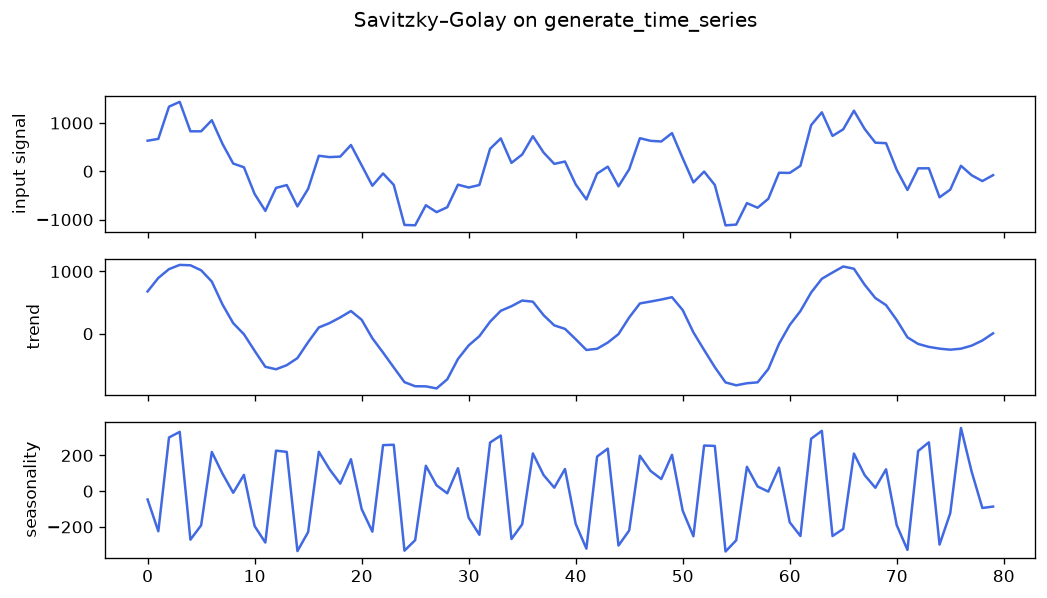

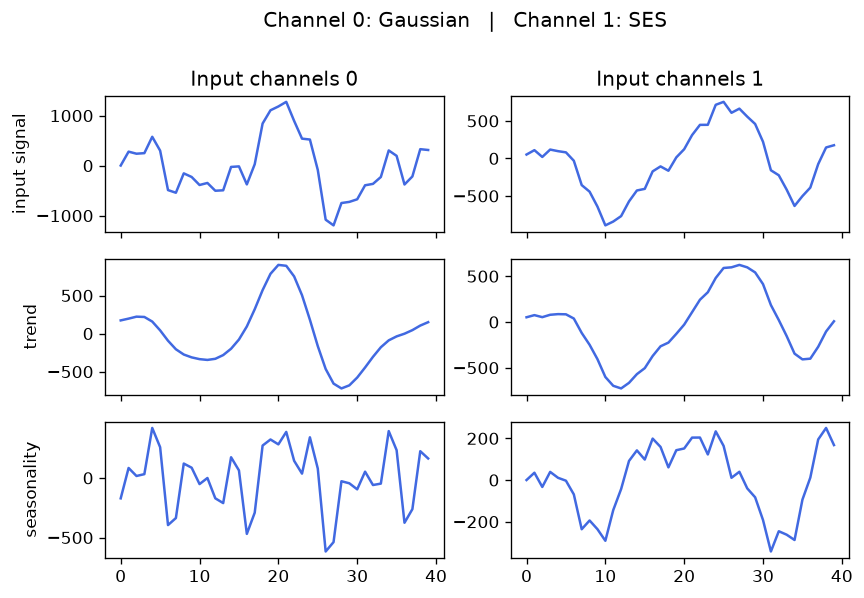

In [6]:
series = generate_time_series(duration=80, seed=42)[-500:]
print("univariate length (after burn-in crop):", series.size)

md = Moving_Decomp(window_size=11, method="savgol")
trend, season = md(series)  # __call__ == fit_transform
fig = md.plot_decomposition(series, trend, season)
fig.suptitle("Savitzky–Golay on generate_time_series", y=1.02)
plt.show()

multi = np.vstack(
    [
        generate_time_series(duration=40, periodicities=np.array([10, 20, 30]), seed=0)[
            -400:
        ],
        generate_time_series(duration=40, periodicities=np.array([8, 24, 40]), seed=1)[
            -400:
        ],
    ]
)
trend_m, season_m = Moving_Decomp(window_size=9).fit_transform(
    multi, methods_list=["gaussian", "exponential"]
)
print("multivariate shape:", multi.shape, "->", trend_m.shape)
fig_m = Moving_Decomp.plot_decomposition(multi, trend_m, season_m)
fig_m.suptitle("Channel 0: Gaussian   |   Channel 1: SES", y=1.02)
plt.show()

## 9. Practical notes

| Situation | Prefer |
|---|---|
| Offline series, centred trend, no strong curvature | `simple` or `gaussian` |
| Trend has smooth bends you want to keep | `savgol` (`poly_order=2` or `3`, odd `window_size`) |
| Streaming / causal estimate | `exponential` (tune `alpha`) |
| You only care about a remainder with $T+S=y$ exactly | any method — reconstruction is an identity |

- `window_size` should be **odd** when using Savitzky–Golay (`savgol_smoothing` asserts this).
- `gaussian` ignores `window_size` and uses `sigma`; `exponential` ignores `window_size` and uses `alpha`.
- This is **not** STL: there is a single seasonal remainder, not a LOESS inner/outer loop with a fixed period.  For multiple seasonal periods see `STL` / `MSTL` in the same `pysdkit.tsa` package.
